# Group 148 - Robust Reinforcement Learning under Stochastic Action Failure

**Assignment II | DQN and DDQN on LunarLander-v3**

## Group contribution declaration

- Shivam Kumar: 20%
- Nunna Swahan Bapaji: 20%
- Garimella Nikhitha: 20%
- S H Aishwarya: 20%
- Omkareshwar Vaijanath Telee: 20%

**Declaration status:** FINAL. The percentages total 100%.

> The institutional virtual-lab screenshot is embedded only when a genuine capture exists at the documented evidence path.

## Objective and experimental question

We test whether hidden 15% thruster-command failures make value estimation and credit assignment more difficult, and whether Double DQN is more robust than DQN when every attempted thruster action also costs 0.3 reward units.

The success criteria are exact wrapper conformance, fair algorithm comparison, four required training plots, strict safe-landing measurement, and reproducible episode-level evidence.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

repo_candidates = [Path.cwd(), *Path.cwd().parents]
REPO = next(path for path in repo_candidates if (path / 'pyproject.toml').exists())
sys.path.insert(0, str(REPO / 'src'))
ARTIFACTS = REPO / 'artifacts'
print('Repository:', REPO)
print('Artifacts:', ARTIFACTS)


Repository: /Users/shivamkumar/Documents/Codex/drl-asginrmnet-2
Artifacts: /Users/shivamkumar/Documents/Codex/drl-asginrmnet-2/artifacts


## Exact environment modification

For selected action $a$, executed action $a_{exec}$ is replaced by 0 with probability 0.15 only when $a \in \{1,2,3\}$. The agent receives no failure flag. The returned reward is

$$R = R_{base} - 0.3\,\mathbf{1}(a \ne 0) + B,$$

where $B=50$ only for a non-truncated terminal transition with both legs in contact and absolute horizontal velocity, vertical velocity, and angle all strictly below 0.10.

In [2]:
from robust_lunarlander.envs import StochasticActionFailureWrapper, is_safe_landing
from robust_lunarlander.verification import run_controlled_boundary_verification

boundary_results = run_controlled_boundary_verification()
display(boundary_results)
assert boundary_results['passed'].all()


,case,selected_action,executed_action,expected_executed_action,safe_landing_detected,expected_bonus,observed_reward,expected_reward,fuel_penalty,info_identity_preserved,passed
0,all_conditions_true,0,0,0,True,50.0,57.0,57.0,0.0,True,True
1,attempted_thruster_success,2,2,2,True,50.0,56.7,56.7,0.3,True,True
2,attempted_thruster_misfire,2,0,0,True,50.0,56.7,56.7,0.3,True,True
3,not_terminated,0,0,0,False,0.0,7.0,7.0,0.0,True,True
4,episode_truncated,0,0,0,False,0.0,7.0,7.0,0.0,True,True
5,left_leg_absent,0,0,0,False,0.0,7.0,7.0,0.0,True,True
6,right_leg_absent,0,0,0,False,0.0,7.0,7.0,0.0,True,True
7,horizontal_velocity_boundary,0,0,0,False,0.0,7.0,7.0,0.0,True,True
8,vertical_velocity_boundary,0,0,0,False,0.0,7.0,7.0,0.0,True,True
9,orientation_boundary,0,0,0,False,0.0,7.0,7.0,0.0,True,True


## Random-policy verification

The external spy observed 2,502 misfires among 16,465 attempted thruster actions across 250 episodes: **15%** (unrounded rate 0.151959). The 15% target lies inside the Wilson 95% interval. Fuel-penalty mismatches, unexpected replacements, and info-object changes were all zero.

In [3]:
verification = json.loads((ARTIFACTS / 'verification' / 'wrapper_verification.json').read_text())
random_policy_table = pd.json_normalize(verification['random_policy'])
display(random_policy_table.T.rename(columns={0: 'value'}))
assert verification['overall_passed']


,value
episodes,250
total_steps,21917
attempted_thruster_actions,16465
misfired_thruster_actions,2502
observed_misfire_rate,0.151959
target_misfire_rate,0.15
misfire_rate_absolute_error,0.001959
misfire_rate_wilson_95_low,0.146557
misfire_rate_wilson_95_high,0.157523
target_inside_wilson_interval,True


## Fair DQN/DDQN design

All four agents use seed 148, 800 episodes, an 8-128-128-4 ReLU network, Adam with learning rate 0.0005, replay capacity 100,000, batch size 64, discount 0.99, linear epsilon decay from 1.00 to 0.01 over 100,000 steps, and a hard target copy every 500 updates. A single SHA-256-hashed set of 512 validation states is reused at every episode.

DQN evaluates $\max_a Q_{target}(s',a)$. DDQN selects the maximizing action with the online network and evaluates only that action with the target network. This is the sole algorithm branch.

In [4]:
config = json.loads((ARTIFACTS / 'training_config.json').read_text())
provenance = json.loads((ARTIFACTS / 'system_provenance.json').read_text())
display(pd.DataFrame({'value': config}).head(30))
print('Fixed validation SHA-256:', provenance['validation_set_sha256'])


,value
seed,148
episodes,800
max_steps_per_episode,1000
gamma,0.99
learning_rate,0.0005
batch_size,64
replay_capacity,100000
learning_starts,1000
train_frequency,1
target_update_interval,500


Fixed validation SHA-256: b765a8c76d9ffa0e93207cc98d3bda2bf16adca80d38c8871380e832e25c7f8a


## Required performance plots

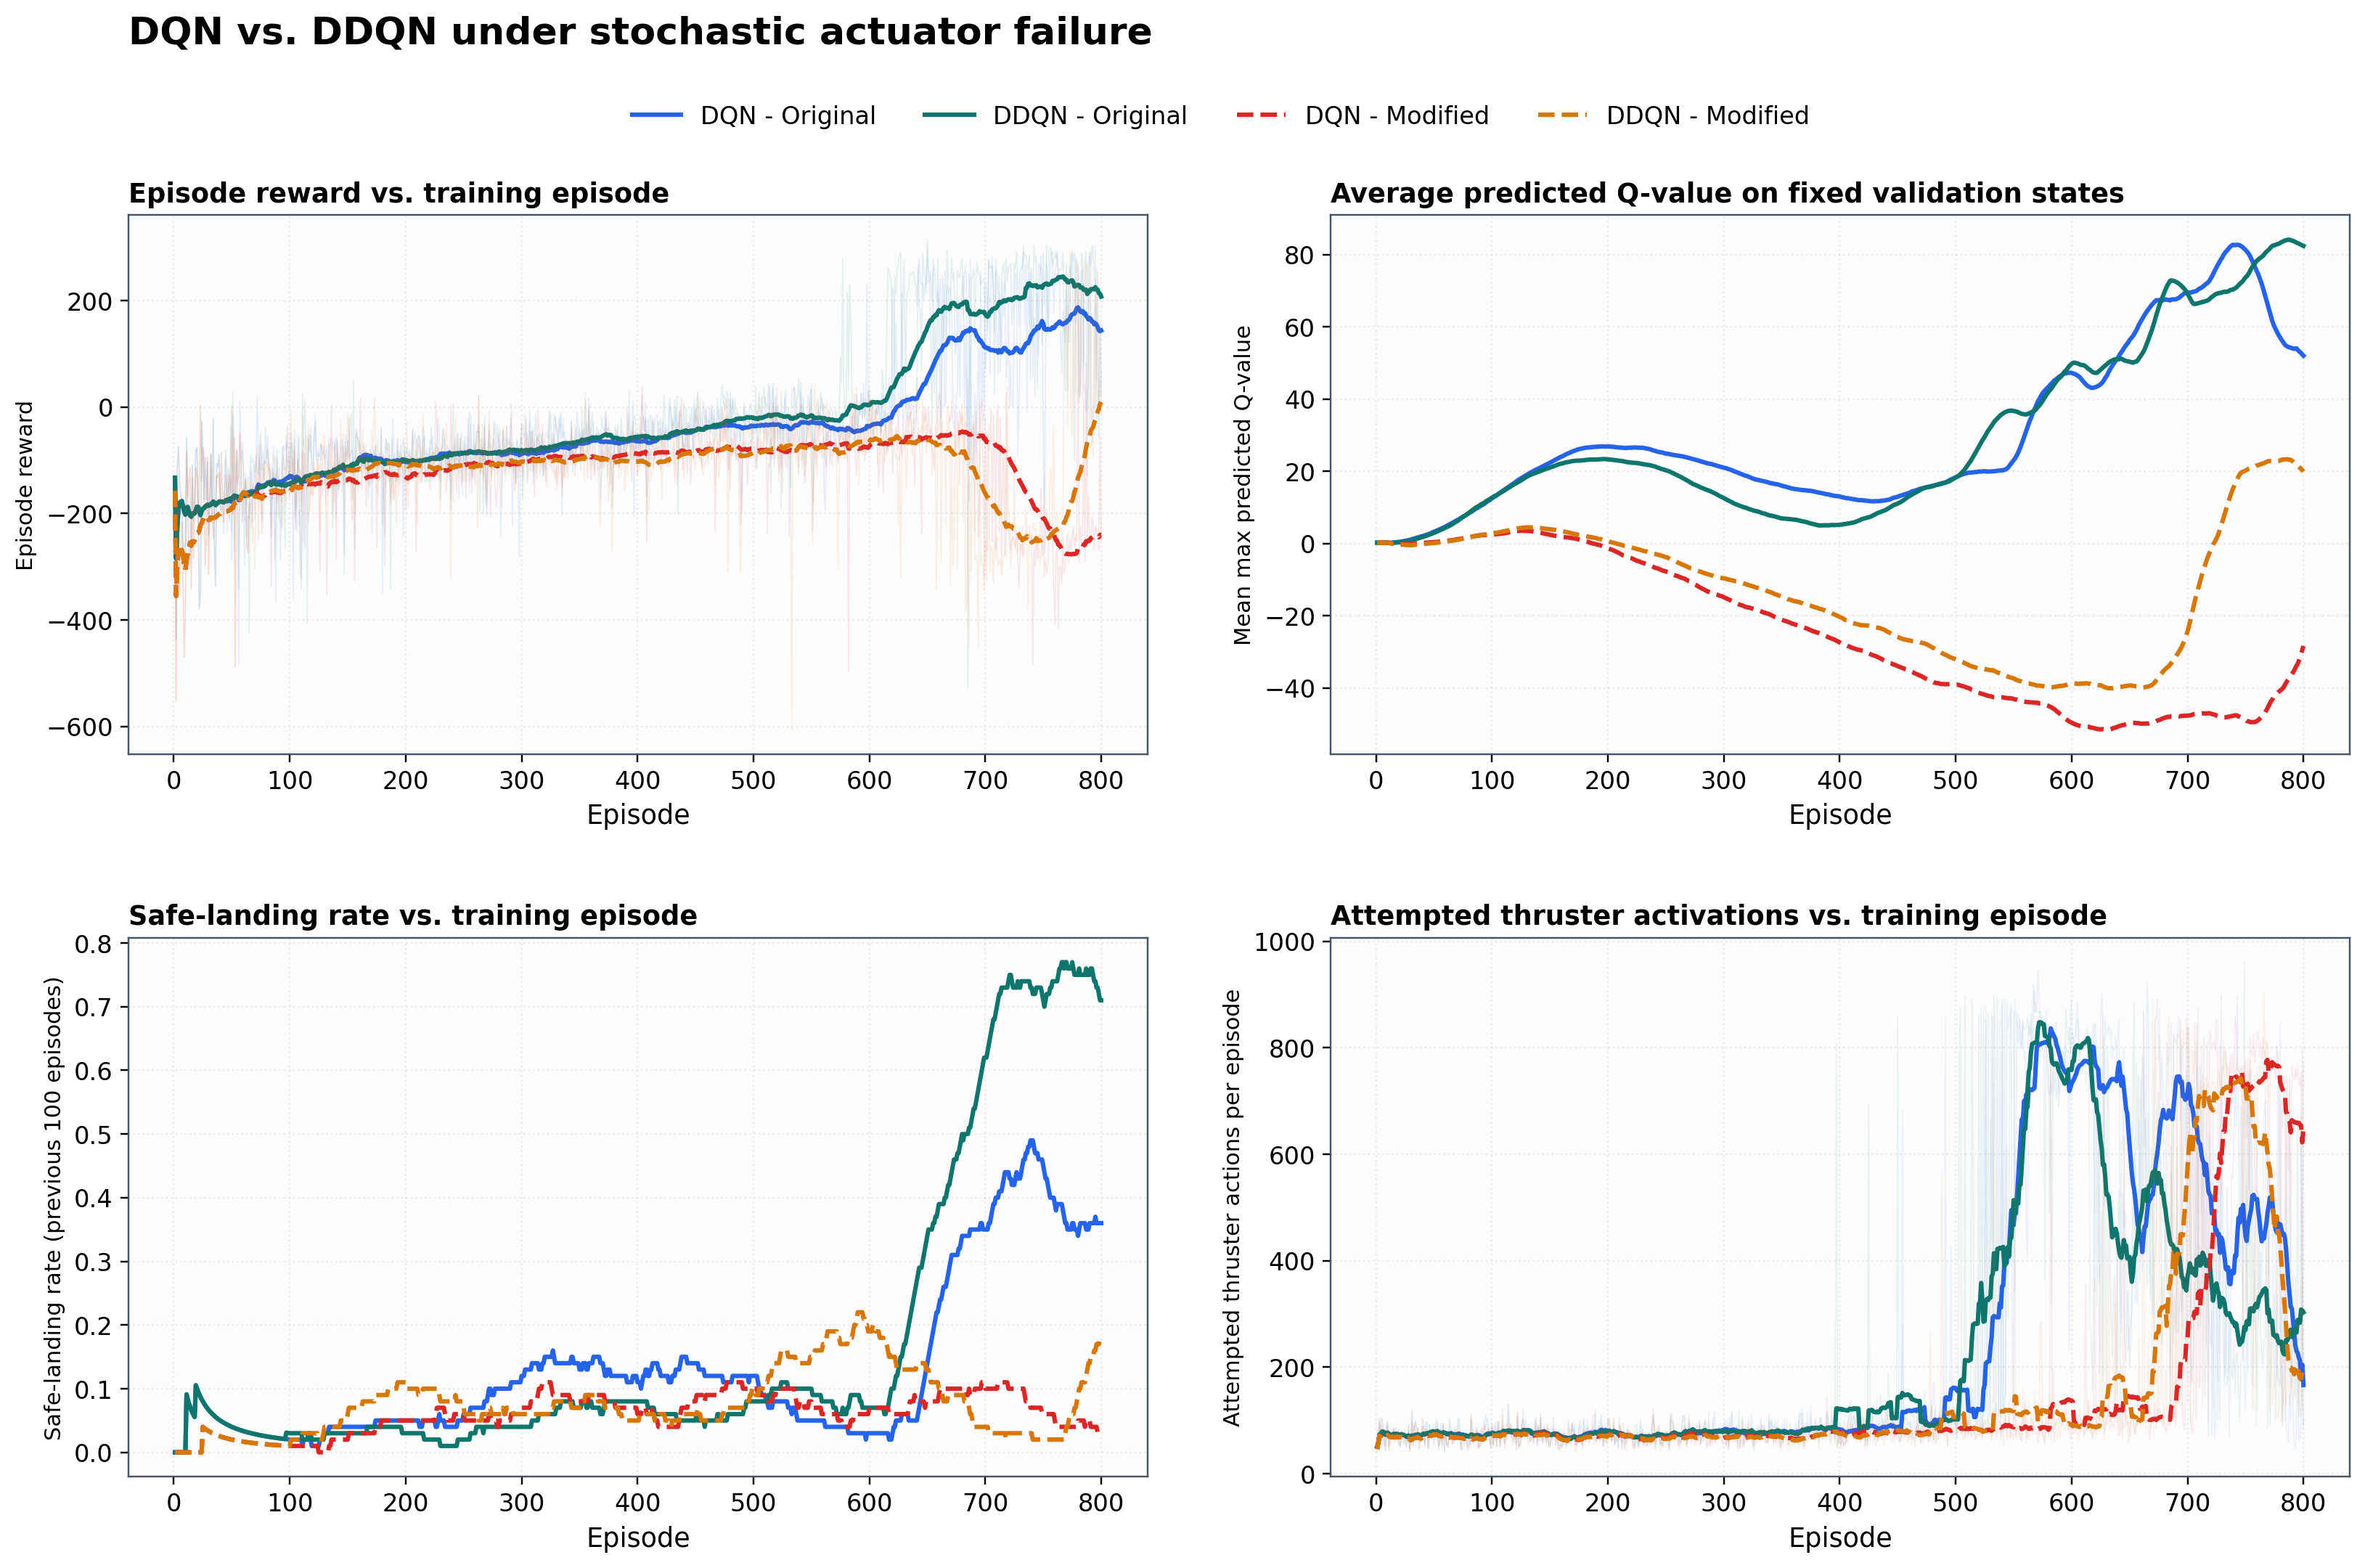

In [5]:
overview_path = ARTIFACTS / 'plots' / 'four_metric_overview.png'
display(Image(filename=str(overview_path), width=1100))


### Plot interpretations

1. **Episode reward.** Both original-environment agents improve sharply after roughly episode 600; DDQN finishes higher. Modified-environment learning is less stable. DDQN recovers late, while DQN remains in a poor high-activation policy.

2. **Average predicted Q-value.** The final-100 mean absolute DQN-DDQN gap is 16.23 on the original environment and 58.30 on the modified environment. The measured increase is 42.08.

3. **Safe-landing rate.** The strict 100-episode moving rate ends at 71% for DDQN-original, 36% for DQN-original, 18% for DDQN-modified, and 3% for DQN-modified.

4. **Thruster activations.** Counts reveal late high-activation regimes. In greedy evaluation, DDQN-modified uses fewer attempts than DDQN-original; DQN-modified instead shows a failed, inefficient policy.

## Greedy evaluation on 100 shared seeds

In [6]:
evaluation = pd.read_csv(ARTIFACTS / 'evaluation_summary.csv')
display(evaluation.style.format({'mean_reward': '{:.2f}', 'reward_std': '{:.2f}', 'safe_landing_rate': '{:.0%}', 'mean_thruster_activations': '{:.2f}', 'mean_episode_steps': '{:.2f}'}))


,experiment,algorithm,environment,mean_reward,reward_std,safe_landing_rate,mean_thruster_activations,mean_episode_steps
0,ddqn_modified,DDQN,Modified,87.73,135.66,32%,166.23,255.73
1,ddqn_original,DDQN,Original,169.05,136.75,61%,250.72,360.51
2,dqn_modified,DQN,Modified,-217.58,94.02,3%,710.45,959.37
3,dqn_original,DQN,Original,67.15,95.71,24%,138.07,188.34


## Discussion

### 1. Does failure increase the DQN-DDQN Q-value difference?

Yes for this seeded run. The final-100 mean absolute gap increases from 16.23 to 58.30. This is empirical evidence for the configured run, not a multi-seed population estimate.

### 2. Why is credit assignment harder?

The same selected thruster action can produce either a physical impulse or no impulse, yet the agent sees neither the replacement nor a failure flag. Replay therefore contains higher-variance outcomes for apparently identical state-action pairs. The attempted-action penalty is charged in both cases, which further separates immediate cost from uncertain physical effect.

### 3. Does the penalty produce a conservative strategy?

Evidence is conditional. DDQN's greedy modified policy averages 166.23 attempts, below DDQN-original's 250.72. DQN-modified averages 710.45, so the penalty alone does not guarantee conservation when learning collapses.

### 4. Which algorithm is better under failures?

DDQN. Its modified-environment greedy mean reward is 87.73 with 32% safe landings, versus DQN's -217.58 and 3%. This is consistent with Double DQN's theoretical motivation of decoupling action selection and evaluation to reduce harmful maximization bias.

### 5. Limitation and improvement

The principal limitation is one training seed. Repeat the full 2 x 2 design over at least 10 pre-registered seeds and report bootstrap confidence intervals or a hierarchical model for reward, safe-landing rate, Q-gap, and thruster use.

## Virtual-lab timestamp evidence

The following cell embeds the required screenshot only when the genuine institutional virtual-lab capture is present.

In [7]:
virtual_lab_image = (
    REPO / 'submission' / 'virtual_lab' / 'virtual_lab_timestamp.png'
)
if virtual_lab_image.exists():
    display(Image(filename=str(virtual_lab_image), width=1000))
else:
    print('MANDATORY EVIDENCE PENDING: follow docs/virtual_lab_runbook.md')


MANDATORY EVIDENCE PENDING: follow docs/virtual_lab_runbook.md


## References

1. Mnih et al. (2015), *Human-level control through deep reinforcement learning*, Nature 518, 529-533. DOI: 10.1038/nature14236.
2. van Hasselt, Guez, and Silver (2016), *Deep Reinforcement Learning with Double Q-Learning*, AAAI 30(1). DOI: 10.1609/aaai.v30i1.10295.
3. Farama Foundation, *Gymnasium LunarLander-v3 documentation*.

# Complete commented source appendix

Every implementation function is documented. The listings below are generated directly from the same modules used to produce the committed outputs.

### src/robust_lunarlander/config.py

```python
"""Central configuration for fair and reproducible DQN/DDQN experiments."""

from __future__ import annotations

from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any


@dataclass(frozen=True)
class TrainingConfig:
    """Store every experimental choice shared by all four training runs."""

    seed: int = 148
    episodes: int = 800
    max_steps_per_episode: int = 1_000
    gamma: float = 0.99
    learning_rate: float = 5e-4
    batch_size: int = 64
    replay_capacity: int = 100_000
    learning_starts: int = 1_000
    train_frequency: int = 1
    target_update_interval: int = 500
    epsilon_start: float = 1.0
    epsilon_end: float = 0.01
    epsilon_decay_steps: int = 100_000
    hidden_sizes: tuple[int, int] = (128, 128)
    gradient_clip_norm: float = 10.0
    validation_state_count: int = 512
    evaluation_episodes: int = 100
    failure_probability: float = 0.15
    attempted_thruster_penalty: float = 0.3
    safe_landing_bonus: float = 50.0
    device: str = "cpu"
    output_dir: Path = Path("artifacts")

    def as_serializable_dict(self) -> dict[str, Any]:
        """Return a JSON-safe representation suitable for provenance files."""

        values = asdict(self)
        values["output_dir"] = str(self.output_dir)
        values["hidden_sizes"] = list(self.hidden_sizes)
        return values


def linear_epsilon(step: int, config: TrainingConfig) -> float:
    """Linearly anneal epsilon from its start value to its final value."""

    progress = min(max(step, 0) / config.epsilon_decay_steps, 1.0)
    return config.epsilon_start + progress * (config.epsilon_end - config.epsilon_start)
```


### src/robust_lunarlander/envs.py

```python
"""Environment construction and the assignment-specified action-failure wrapper."""

from __future__ import annotations

from typing import Any

import gymnasium as gym
import numpy as np


def is_safe_landing(
    observation: np.ndarray,
    terminated: bool,
    truncated: bool,
) -> bool:
    """Return True only when every assignment safe-landing condition is met."""

    observation = np.asarray(observation)
    return bool(
        terminated
        and not truncated
        and observation[6] == 1
        and observation[7] == 1
        and abs(float(observation[2])) < 0.10
        and abs(float(observation[3])) < 0.10
        and abs(float(observation[4])) < 0.10
    )


class StochasticActionFailureWrapper(gym.Wrapper):
    """Apply hidden thruster failures, attempted-fuel cost, and safe-landing bonus.

    The selected action is retained only within step. The returned observation,
    termination flags, truncation flag, and info object come directly from the base
    environment. In particular, no failure indicator is leaked to the agent.
    """

    def __init__(
        self,
        env: gym.Env,
        failure_probability: float = 0.15,
        attempted_thruster_penalty: float = 0.3,
        safe_landing_bonus: float = 50.0,
    ) -> None:
        """Initialize the wrapper while preserving the base action and observation spaces."""

        super().__init__(env)
        if not 0.0 <= failure_probability <= 1.0:
            raise ValueError("failure_probability must lie in [0, 1].")
        if attempted_thruster_penalty < 0.0:
            raise ValueError("attempted_thruster_penalty must be non-negative.")
        self.failure_probability = float(failure_probability)
        self.attempted_thruster_penalty = float(attempted_thruster_penalty)
        self.safe_landing_bonus = float(safe_landing_bonus)

    def step(
        self,
        action: int,
    ) -> tuple[np.ndarray, float, bool, bool, dict[str, Any]]:
        """Execute one assignment-compliant transition in the specified order."""

        selected_action = int(action)
        if not self.action_space.contains(selected_action):
            raise ValueError(f"Invalid action {selected_action!r} for {self.action_space}.")

        executed_action = selected_action
        if selected_action in (1, 2, 3) and self.np_random.random() < self.failure_probability:
            executed_action = 0

        observation, base_reward, terminated, truncated, info = self.env.step(executed_action)

        fuel_cost = self.attempted_thruster_penalty if selected_action != 0 else 0.0
        landing_bonus = (
            self.safe_landing_bonus if is_safe_landing(observation, terminated, truncated) else 0.0
        )
        modified_reward = float(base_reward) - fuel_cost + landing_bonus

        return observation, modified_reward, terminated, truncated, info


def make_environment(
    *,
    modified: bool,
    failure_probability: float = 0.15,
    attempted_thruster_penalty: float = 0.3,
    safe_landing_bonus: float = 50.0,
    render_mode: str | None = None,
) -> gym.Env:
    """Create either original LunarLander-v3 or the specified modified variant."""

    base_environment = gym.make("LunarLander-v3", render_mode=render_mode)
    if not modified:
        return base_environment
    return StochasticActionFailureWrapper(
        base_environment,
        failure_probability=failure_probability,
        attempted_thruster_penalty=attempted_thruster_penalty,
        safe_landing_bonus=safe_landing_bonus,
    )
```


### src/robust_lunarlander/network.py

```python
"""Neural-network definition shared without alteration by DQN and DDQN."""

from __future__ import annotations

from collections.abc import Sequence

import torch
from torch import nn


class QNetwork(nn.Module):
    """Map an eight-dimensional LunarLander state to four action values."""

    def __init__(
        self,
        observation_size: int,
        action_count: int,
        hidden_sizes: Sequence[int] = (128, 128),
    ) -> None:
        """Build a multilayer perceptron with ReLU hidden activations."""

        super().__init__()
        dimensions = [observation_size, *hidden_sizes, action_count]
        layers: list[nn.Module] = []
        for input_size, output_size in zip(dimensions[:-2], dimensions[1:-1], strict=True):
            layers.extend((nn.Linear(input_size, output_size), nn.ReLU()))
        layers.append(nn.Linear(dimensions[-2], dimensions[-1]))
        self.model = nn.Sequential(*layers)

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        """Return one predicted Q-value per discrete action."""

        return self.model(observations)
```


### src/robust_lunarlander/replay.py

```python
"""Preallocated experience replay used identically by DQN and DDQN."""

from __future__ import annotations

from typing import NamedTuple

import numpy as np
import torch


class ReplayBatch(NamedTuple):
    """Hold one tensor batch sampled uniformly from replay memory."""

    observations: torch.Tensor
    actions: torch.Tensor
    rewards: torch.Tensor
    next_observations: torch.Tensor
    dones: torch.Tensor


class ReplayBuffer:
    """Store transitions in a fixed-size circular buffer."""

    def __init__(
        self,
        capacity: int,
        observation_size: int,
        seed: int,
    ) -> None:
        """Allocate storage once and initialize an isolated sampling generator."""

        self.capacity = int(capacity)
        self.observations = np.empty((capacity, observation_size), dtype=np.float32)
        self.actions = np.empty(capacity, dtype=np.int64)
        self.rewards = np.empty(capacity, dtype=np.float32)
        self.next_observations = np.empty((capacity, observation_size), dtype=np.float32)
        self.dones = np.empty(capacity, dtype=np.float32)
        self.position = 0
        self.size = 0
        self.rng = np.random.default_rng(seed)

    def add(
        self,
        observation: np.ndarray,
        action: int,
        reward: float,
        next_observation: np.ndarray,
        done: bool,
    ) -> None:
        """Insert one transition, overwriting the oldest transition when full."""

        index = self.position
        self.observations[index] = observation
        self.actions[index] = action
        self.rewards[index] = reward
        self.next_observations[index] = next_observation
        self.dones[index] = float(done)
        self.position = (self.position + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size: int, device: torch.device) -> ReplayBatch:
        """Sample transitions uniformly and move the resulting tensors to a device."""

        if self.size < batch_size:
            raise ValueError("Cannot sample more transitions than the buffer currently stores.")
        indices = self.rng.integers(0, self.size, size=batch_size)
        return ReplayBatch(
            torch.as_tensor(self.observations[indices], device=device),
            torch.as_tensor(self.actions[indices], device=device).unsqueeze(1),
            torch.as_tensor(self.rewards[indices], device=device).unsqueeze(1),
            torch.as_tensor(self.next_observations[indices], device=device),
            torch.as_tensor(self.dones[indices], device=device).unsqueeze(1),
        )

    def __len__(self) -> int:
        """Return the number of valid transitions currently stored."""

        return self.size
```


### src/robust_lunarlander/agent.py

```python
"""A single agent implementation whose target calculation selects DQN or DDQN."""

from __future__ import annotations

from typing import Literal

import numpy as np
import torch
from torch import nn

from .config import TrainingConfig
from .network import QNetwork
from .replay import ReplayBatch, ReplayBuffer

Algorithm = Literal["dqn", "ddqn"]


class ValueAgent:
    """Train DQN or DDQN with an otherwise identical architecture and optimizer."""

    def __init__(
        self,
        observation_size: int,
        action_count: int,
        algorithm: Algorithm,
        config: TrainingConfig,
    ) -> None:
        """Create online/target networks, Adam optimizer, replay memory, and RNG."""

        if algorithm not in ("dqn", "ddqn"):
            raise ValueError("algorithm must be either 'dqn' or 'ddqn'.")
        self.algorithm = algorithm
        self.action_count = action_count
        self.config = config
        self.device = torch.device(config.device)
        self.rng = np.random.default_rng(config.seed)

        self.online_network = QNetwork(
            observation_size,
            action_count,
            config.hidden_sizes,
        ).to(self.device)
        self.target_network = QNetwork(
            observation_size,
            action_count,
            config.hidden_sizes,
        ).to(self.device)
        self.target_network.load_state_dict(self.online_network.state_dict())
        self.target_network.eval()

        self.optimizer = torch.optim.Adam(
            self.online_network.parameters(),
            lr=config.learning_rate,
        )
        self.loss_function = nn.SmoothL1Loss()
        self.replay = ReplayBuffer(
            config.replay_capacity,
            observation_size,
            config.seed + 1,
        )
        self.update_count = 0

    def select_action(self, observation: np.ndarray, epsilon: float) -> int:
        """Choose a random action with probability epsilon, otherwise act greedily."""

        if self.rng.random() < epsilon:
            return int(self.rng.integers(self.action_count))
        with torch.no_grad():
            state = torch.as_tensor(
                observation,
                dtype=torch.float32,
                device=self.device,
            ).unsqueeze(0)
            return int(self.online_network(state).argmax(dim=1).item())

    def _bootstrap_values(self, batch: ReplayBatch) -> torch.Tensor:
        """Compute the only algorithm-specific term: the next-state target value."""

        with torch.no_grad():
            if self.algorithm == "dqn":
                return self.target_network(batch.next_observations).max(dim=1, keepdim=True).values

            online_actions = self.online_network(batch.next_observations).argmax(
                dim=1,
                keepdim=True,
            )
            return self.target_network(batch.next_observations).gather(1, online_actions)

    def update(self) -> float:
        """Perform one replay-based temporal-difference optimization step."""

        batch = self.replay.sample(self.config.batch_size, self.device)
        predicted_values = self.online_network(batch.observations).gather(1, batch.actions)
        bootstrap_values = self._bootstrap_values(batch)
        target_values = batch.rewards + self.config.gamma * (1.0 - batch.dones) * bootstrap_values

        loss = self.loss_function(predicted_values, target_values)
        self.optimizer.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(
            self.online_network.parameters(),
            self.config.gradient_clip_norm,
        )
        self.optimizer.step()

        self.update_count += 1
        if self.update_count % self.config.target_update_interval == 0:
            self.target_network.load_state_dict(self.online_network.state_dict())
        return float(loss.item())

    def average_max_q(self, validation_states: np.ndarray) -> float:
        """Measure mean max action value on one unchanged validation-state set."""

        with torch.no_grad():
            states = torch.as_tensor(
                validation_states,
                dtype=torch.float32,
                device=self.device,
            )
            values = self.online_network(states).max(dim=1).values
        return float(values.mean().item())

    def save(self, path: str) -> None:
        """Persist trained weights and the experimental configuration."""

        torch.save(
            {
                "algorithm": self.algorithm,
                "online_network": self.online_network.state_dict(),
                "target_network": self.target_network.state_dict(),
                "optimizer": self.optimizer.state_dict(),
                "config": self.config.as_serializable_dict(),
            },
            path,
        )

    def load(self, path: str) -> None:
        """Restore online and target weights from a saved checkpoint."""

        checkpoint = torch.load(path, map_location=self.device, weights_only=False)
        if checkpoint["algorithm"] != self.algorithm:
            raise ValueError("Checkpoint algorithm does not match this agent.")
        self.online_network.load_state_dict(checkpoint["online_network"])
        self.target_network.load_state_dict(checkpoint["target_network"])
        self.optimizer.load_state_dict(checkpoint["optimizer"])
```


### src/robust_lunarlander/verification.py

```python
"""Experimental and boundary verification of the modified environment."""

from __future__ import annotations

import argparse
import json
import math
import platform
import sys
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Any

import gymnasium as gym
import numpy as np
import pandas as pd
from gymnasium import spaces

from .envs import StochasticActionFailureWrapper, is_safe_landing


class ActionRewardSpy(gym.Wrapper):
    """Record base-environment inputs and outputs outside the agent-facing wrapper."""

    def __init__(self, env: gym.Env) -> None:
        """Initialize an empty last-transition record."""

        super().__init__(env)
        self.last: dict[str, Any] | None = None

    def step(
        self,
        action: int,
    ) -> tuple[np.ndarray, float, bool, bool, dict[str, Any]]:
        """Forward the action and retain the unmodified response for verification."""

        observation, reward, terminated, truncated, info = self.env.step(action)
        self.last = {
            "executed_action": int(action),
            "observation": np.asarray(observation).copy(),
            "base_reward": float(reward),
            "terminated": bool(terminated),
            "truncated": bool(truncated),
            "info": info,
        }
        return observation, reward, terminated, truncated, info


class ScriptedTerminalEnvironment(gym.Env):
    """Return one specified terminal transition for controlled reward tests."""

    metadata: dict[str, Any] = {}

    def __init__(
        self,
        observation: np.ndarray,
        *,
        base_reward: float = 7.0,
        terminated: bool = True,
        truncated: bool = False,
    ) -> None:
        """Store the exact response that step must return."""

        super().__init__()
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Box(-np.inf, np.inf, shape=(8,), dtype=np.float32)
        self.response_observation = np.asarray(observation, dtype=np.float32)
        self.base_reward = float(base_reward)
        self.terminated = bool(terminated)
        self.truncated = bool(truncated)
        self.received_action: int | None = None
        self.info_object = {"source": "scripted-base"}

    def reset(
        self,
        *,
        seed: int | None = None,
        options: dict[str, Any] | None = None,
    ) -> tuple[np.ndarray, dict[str, Any]]:
        """Reset Gymnasium's random generator and return a neutral observation."""

        super().reset(seed=seed)
        del options
        return np.zeros(8, dtype=np.float32), {}

    def step(
        self,
        action: int,
    ) -> tuple[np.ndarray, float, bool, bool, dict[str, Any]]:
        """Return the configured response while recording the executed action."""

        self.received_action = int(action)
        return (
            self.response_observation.copy(),
            self.base_reward,
            self.terminated,
            self.truncated,
            self.info_object,
        )


@dataclass(frozen=True)
class BoundaryCase:
    """Describe one controlled safe-landing or fuel-penalty check."""

    name: str
    observation: list[float]
    terminated: bool
    truncated: bool
    selected_action: int
    failure_probability: float
    expected_bonus: float
    expected_executed_action: int


def _safe_observation() -> np.ndarray:
    """Return an observation satisfying all five state thresholds."""

    return np.array([0.0, 0.0, 0.02, -0.03, 0.04, 0.0, 1.0, 1.0], dtype=np.float32)


def controlled_boundary_cases() -> list[BoundaryCase]:
    """Enumerate positive, negative, boundary, truncation, and misfire cases."""

    safe = _safe_observation()
    cases: list[BoundaryCase] = [
        BoundaryCase("all_conditions_true", safe.tolist(), True, False, 0, 0.0, 50.0, 0),
        BoundaryCase("attempted_thruster_success", safe.tolist(), True, False, 2, 0.0, 50.0, 2),
        BoundaryCase("attempted_thruster_misfire", safe.tolist(), True, False, 2, 1.0, 50.0, 0),
    ]
    mutations = [
        ("not_terminated", 2, 0.02, False, False),
        ("episode_truncated", 2, 0.02, True, True),
        ("left_leg_absent", 6, 0.0, True, False),
        ("right_leg_absent", 7, 0.0, True, False),
        ("horizontal_velocity_boundary", 2, 0.10, True, False),
        ("vertical_velocity_boundary", 3, -0.10, True, False),
        ("orientation_boundary", 4, 0.10, True, False),
    ]
    for name, index, value, terminated, truncated in mutations:
        observation = safe.copy()
        observation[index] = value
        cases.append(
            BoundaryCase(
                name,
                observation.tolist(),
                terminated,
                truncated,
                0,
                0.0,
                0.0,
                0,
            )
        )
    return cases


def run_controlled_boundary_verification() -> pd.DataFrame:
    """Execute every controlled case and prove exact reward/action semantics."""

    rows: list[dict[str, Any]] = []
    for case in controlled_boundary_cases():
        base = ScriptedTerminalEnvironment(
            np.asarray(case.observation, dtype=np.float32),
            terminated=case.terminated,
            truncated=case.truncated,
        )
        wrapped = StochasticActionFailureWrapper(
            base,
            failure_probability=case.failure_probability,
        )
        wrapped.reset(seed=148)
        observation, reward, terminated, truncated, returned_info = wrapped.step(
            case.selected_action
        )
        expected_penalty = 0.3 if case.selected_action != 0 else 0.0
        expected_reward = base.base_reward - expected_penalty + case.expected_bonus
        rows.append(
            {
                "case": case.name,
                "selected_action": case.selected_action,
                "executed_action": base.received_action,
                "expected_executed_action": case.expected_executed_action,
                "safe_landing_detected": is_safe_landing(observation, terminated, truncated),
                "expected_bonus": case.expected_bonus,
                "observed_reward": float(reward),
                "expected_reward": expected_reward,
                "fuel_penalty": expected_penalty,
                "info_identity_preserved": returned_info is base.info_object,
                "passed": bool(
                    base.received_action == case.expected_executed_action
                    and math.isclose(float(reward), expected_reward, abs_tol=1e-7)
                    and returned_info is base.info_object
                ),
            }
        )
        wrapped.close()
    return pd.DataFrame(rows)


def _wilson_interval(successes: int, trials: int) -> tuple[float, float]:
    """Return a 95 percent Wilson score interval for a binomial proportion."""

    if trials == 0:
        return float("nan"), float("nan")
    z = 1.959963984540054
    proportion = successes / trials
    denominator = 1.0 + z * z / trials
    centre = (proportion + z * z / (2.0 * trials)) / denominator
    radius = (
        z
        * math.sqrt(proportion * (1.0 - proportion) / trials + z * z / (4.0 * trials * trials))
        / denominator
    )
    return centre - radius, centre + radius


def run_random_policy_verification(
    *,
    episodes: int,
    seed: int,
) -> tuple[dict[str, Any], pd.DataFrame]:
    """Run many random LunarLander episodes and compare selected/executed actions."""

    spy = ActionRewardSpy(gym.make("LunarLander-v3"))
    environment = StochasticActionFailureWrapper(spy)
    action_rng = np.random.default_rng(seed + 10_000)
    records: list[dict[str, Any]] = []
    total_steps = 0
    attempted_thrusters = 0
    misfires = 0
    penalty_checks = 0
    penalty_mismatches = 0
    info_identity_mismatches = 0
    unexpected_action_replacements = 0
    observed_safe_landings = 0

    for episode in range(1, episodes + 1):
        observation, _ = environment.reset(seed=seed + episode - 1)
        del observation
        terminated = truncated = False
        episode_step = 0
        while not (terminated or truncated):
            selected_action = int(action_rng.integers(environment.action_space.n))
            observation, reward, terminated, truncated, info = environment.step(selected_action)
            if spy.last is None:
                raise RuntimeError("The verification spy did not record a base transition.")

            executed_action = int(spy.last["executed_action"])
            safe = is_safe_landing(observation, terminated, truncated)
            expected_penalty = 0.3 if selected_action != 0 else 0.0
            expected_bonus = 50.0 if safe else 0.0
            expected_reward = float(spy.last["base_reward"]) - expected_penalty + expected_bonus
            penalty_ok = math.isclose(float(reward), expected_reward, abs_tol=1e-6)

            if selected_action != 0:
                attempted_thrusters += 1
                penalty_checks += 1
                misfires += int(executed_action == 0)
                penalty_mismatches += int(not penalty_ok)
                unexpected_action_replacements += int(executed_action not in (0, selected_action))
            else:
                unexpected_action_replacements += int(executed_action != 0)
            info_identity_mismatches += int(info is not spy.last["info"])
            observed_safe_landings += int(safe)
            total_steps += 1
            episode_step += 1

            if len(records) < 500:
                records.append(
                    {
                        "episode": episode,
                        "step": episode_step,
                        "selected_action": selected_action,
                        "executed_action": executed_action,
                        "misfire": selected_action != 0 and executed_action == 0,
                        "base_reward": float(spy.last["base_reward"]),
                        "modified_reward": float(reward),
                        "expected_fuel_penalty": expected_penalty,
                        "safe_landing_bonus": expected_bonus,
                        "reward_check_passed": penalty_ok,
                    }
                )

    environment.close()
    interval_low, interval_high = _wilson_interval(misfires, attempted_thrusters)
    observed_rate = misfires / attempted_thrusters
    summary = {
        "episodes": episodes,
        "total_steps": total_steps,
        "attempted_thruster_actions": attempted_thrusters,
        "misfired_thruster_actions": misfires,
        "observed_misfire_rate": observed_rate,
        "target_misfire_rate": 0.15,
        "misfire_rate_absolute_error": abs(observed_rate - 0.15),
        "misfire_rate_wilson_95_low": interval_low,
        "misfire_rate_wilson_95_high": interval_high,
        "target_inside_wilson_interval": interval_low <= 0.15 <= interval_high,
        "fuel_penalty_checks": penalty_checks,
        "fuel_penalty_mismatches": penalty_mismatches,
        "info_identity_mismatches": info_identity_mismatches,
        "unexpected_action_replacements": unexpected_action_replacements,
        "safe_landings_observed_under_random_policy": observed_safe_landings,
        "passed": bool(
            interval_low <= 0.15 <= interval_high
            and penalty_mismatches == 0
            and info_identity_mismatches == 0
            and unexpected_action_replacements == 0
        ),
    }
    return summary, pd.DataFrame(records)


def save_verification_artifacts(
    *,
    output_dir: Path,
    episodes: int,
    seed: int,
) -> dict[str, Any]:
    """Run all checks and write machine-readable evidence files."""

    output_dir.mkdir(parents=True, exist_ok=True)
    boundary_results = run_controlled_boundary_verification()
    random_summary, random_samples = run_random_policy_verification(
        episodes=episodes,
        seed=seed,
    )
    summary = {
        "generated_at": datetime.now().astimezone().isoformat(timespec="seconds"),
        "seed": seed,
        "python_version": sys.version.split()[0],
        "platform": platform.platform(),
        "gymnasium_version": gym.__version__,
        "random_policy": random_summary,
        "controlled_boundary_cases": {
            "count": int(len(boundary_results)),
            "passed": int(boundary_results["passed"].sum()),
            "all_passed": bool(boundary_results["passed"].all()),
        },
        "overall_passed": bool(random_summary["passed"] and boundary_results["passed"].all()),
    }
    (output_dir / "wrapper_verification.json").write_text(
        json.dumps(summary, indent=2) + "\n",
        encoding="utf-8",
    )
    boundary_results.to_csv(output_dir / "controlled_boundary_cases.csv", index=False)
    random_samples.to_csv(output_dir / "random_policy_transition_sample.csv", index=False)
    return summary


def main() -> None:
    """Parse command-line options and produce the complete verification bundle."""

    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--episodes", type=int, default=250)
    parser.add_argument("--seed", type=int, default=148)
    parser.add_argument(
        "--output-dir",
        type=Path,
        default=Path("artifacts/verification"),
    )
    args = parser.parse_args()
    summary = save_verification_artifacts(
        output_dir=args.output_dir,
        episodes=args.episodes,
        seed=args.seed,
    )
    print(json.dumps(summary, indent=2))
    if not summary["overall_passed"]:
        raise SystemExit("Wrapper verification failed.")


if __name__ == "__main__":
    main()
```


### src/robust_lunarlander/experiment.py

```python
"""Reproducible training, evaluation, and evidence generation for all four agents."""

from __future__ import annotations

import argparse
import hashlib
import json
import platform
import random
import socket
import sys
import time
from dataclasses import replace
from datetime import datetime
from pathlib import Path
from typing import Any

import gymnasium as gym
import numpy as np
import pandas as pd
import torch

from .agent import Algorithm, ValueAgent
from .config import TrainingConfig, linear_epsilon
from .envs import is_safe_landing, make_environment
from .plotting import create_all_plots, summarize_experiments

EXPERIMENTS: tuple[tuple[Algorithm, bool], ...] = (
    ("dqn", False),
    ("ddqn", False),
    ("dqn", True),
    ("ddqn", True),
)


def experiment_name(algorithm: Algorithm, modified: bool) -> str:
    """Return a stable artifact name for one algorithm/environment pairing."""

    environment_name = "modified" if modified else "original"
    return f"{algorithm}_{environment_name}"


def set_reproducible_seeds(seed: int) -> None:
    """Reset Python, NumPy, and PyTorch generators before every fair run."""

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def collect_fixed_validation_states(
    config: TrainingConfig,
    destination: Path,
) -> np.ndarray:
    """Collect one deterministic random-policy state set shared by all agents."""

    if destination.exists():
        states = np.load(destination)["states"]
        expected_shape = (config.validation_state_count, 8)
        if states.shape != expected_shape:
            raise ValueError(
                f"Existing validation set has shape {states.shape}, expected {expected_shape}."
            )
        return states.astype(np.float32, copy=False)

    environment = make_environment(modified=False)
    action_rng = np.random.default_rng(config.seed + 20_000)
    states: list[np.ndarray] = []
    episode = 0
    while len(states) < config.validation_state_count:
        observation, _ = environment.reset(seed=config.seed + episode)
        terminated = truncated = False
        while not (terminated or truncated) and len(states) < config.validation_state_count:
            states.append(np.asarray(observation, dtype=np.float32).copy())
            action = int(action_rng.integers(environment.action_space.n))
            observation, _, terminated, truncated, _ = environment.step(action)
        episode += 1
    environment.close()

    validation_states = np.stack(states)
    destination.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(destination, states=validation_states)
    return validation_states


def validation_set_sha256(validation_states: np.ndarray) -> str:
    """Hash the exact validation states to prove that all runs use one fixed set."""

    return hashlib.sha256(validation_states.tobytes()).hexdigest()


def train_agent(
    *,
    algorithm: Algorithm,
    modified: bool,
    config: TrainingConfig,
    validation_states: np.ndarray,
    force: bool = False,
) -> pd.DataFrame:
    """Train one agent and write per-episode metrics plus its final checkpoint."""

    name = experiment_name(algorithm, modified)
    metrics_dir = config.output_dir / "metrics"
    checkpoints_dir = config.output_dir / "checkpoints"
    metrics_dir.mkdir(parents=True, exist_ok=True)
    checkpoints_dir.mkdir(parents=True, exist_ok=True)
    metrics_path = metrics_dir / f"{name}.csv"
    checkpoint_path = checkpoints_dir / f"{name}.pt"

    if metrics_path.exists() and checkpoint_path.exists() and not force:
        metrics = pd.read_csv(metrics_path)
        if len(metrics) == config.episodes:
            print(f"[{name}] Reusing complete artifacts ({config.episodes} episodes).", flush=True)
            return metrics

    set_reproducible_seeds(config.seed)
    environment = make_environment(
        modified=modified,
        failure_probability=config.failure_probability,
        attempted_thruster_penalty=config.attempted_thruster_penalty,
        safe_landing_bonus=config.safe_landing_bonus,
    )
    observation_size = int(np.prod(environment.observation_space.shape))
    action_count = int(environment.action_space.n)
    agent = ValueAgent(observation_size, action_count, algorithm, config)

    rows: list[dict[str, Any]] = []
    global_step = 0
    run_started = time.perf_counter()

    for episode in range(1, config.episodes + 1):
        episode_started = time.perf_counter()
        observation, _ = environment.reset(seed=config.seed + episode - 1)
        terminated = truncated = False
        episode_reward = 0.0
        attempted_thrusters = 0
        episode_losses: list[float] = []
        last_observation = np.asarray(observation, dtype=np.float32)
        episode_steps = 0

        for _ in range(config.max_steps_per_episode):
            episode_steps += 1
            epsilon = linear_epsilon(global_step, config)
            action = agent.select_action(observation, epsilon)
            attempted_thrusters += int(action != 0)
            next_observation, reward, terminated, truncated, _ = environment.step(action)
            episode_done = terminated or truncated

            agent.replay.add(
                np.asarray(observation, dtype=np.float32),
                action,
                float(reward),
                np.asarray(next_observation, dtype=np.float32),
                bool(terminated),
            )
            if (
                global_step >= config.learning_starts
                and global_step % config.train_frequency == 0
                and len(agent.replay) >= config.batch_size
            ):
                episode_losses.append(agent.update())

            episode_reward += float(reward)
            observation = next_observation
            last_observation = np.asarray(next_observation, dtype=np.float32)
            global_step += 1
            if episode_done:
                break

        successful_landing = is_safe_landing(last_observation, terminated, truncated)
        previous_successes = [int(row["successful_landing"]) for row in rows[-99:]]
        moving_success_rate = float(np.mean([*previous_successes, int(successful_landing)]))
        average_q = agent.average_max_q(validation_states)
        rows.append(
            {
                "experiment": name,
                "algorithm": algorithm.upper(),
                "environment": "Modified" if modified else "Original",
                "episode": episode,
                "episode_reward": episode_reward,
                "average_predicted_q": average_q,
                "successful_landing": int(successful_landing),
                "success_rate_100": moving_success_rate,
                "thruster_activations": attempted_thrusters,
                "episode_steps": episode_steps,
                "epsilon": linear_epsilon(global_step, config),
                "mean_loss": float(np.mean(episode_losses)) if episode_losses else np.nan,
                "global_step": global_step,
                "episode_seconds": time.perf_counter() - episode_started,
            }
        )

        if episode == 1 or episode % 25 == 0 or episode == config.episodes:
            recent = rows[-50:]
            mean_reward = float(np.mean([row["episode_reward"] for row in recent]))
            mean_thrusters = float(np.mean([row["thruster_activations"] for row in recent]))
            print(
                f"[{name}] episode {episode:4d}/{config.episodes} "
                f"reward50={mean_reward:8.2f} "
                f"success100={moving_success_rate:5.1%} "
                f"q={average_q:8.2f} "
                f"thrusters50={mean_thrusters:6.1f}",
                flush=True,
            )

    environment.close()
    agent.save(str(checkpoint_path))
    metrics = pd.DataFrame(rows)
    metrics.to_csv(metrics_path, index=False)
    elapsed = time.perf_counter() - run_started
    print(f"[{name}] completed in {elapsed / 60.0:.2f} minutes.", flush=True)
    return metrics


def evaluate_agent(
    *,
    algorithm: Algorithm,
    modified: bool,
    config: TrainingConfig,
) -> pd.DataFrame:
    """Evaluate one trained agent greedily over a shared deterministic seed list."""

    name = experiment_name(algorithm, modified)
    checkpoint_path = config.output_dir / "checkpoints" / f"{name}.pt"
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Missing checkpoint: {checkpoint_path}")

    set_reproducible_seeds(config.seed)
    environment = make_environment(
        modified=modified,
        failure_probability=config.failure_probability,
        attempted_thruster_penalty=config.attempted_thruster_penalty,
        safe_landing_bonus=config.safe_landing_bonus,
    )
    observation_size = int(np.prod(environment.observation_space.shape))
    action_count = int(environment.action_space.n)
    agent = ValueAgent(observation_size, action_count, algorithm, config)
    agent.load(str(checkpoint_path))
    rows: list[dict[str, Any]] = []

    for episode in range(1, config.evaluation_episodes + 1):
        observation, _ = environment.reset(seed=config.seed + 100_000 + episode - 1)
        terminated = truncated = False
        episode_reward = 0.0
        attempted_thrusters = 0
        last_observation = np.asarray(observation, dtype=np.float32)
        episode_steps = 0

        for _ in range(config.max_steps_per_episode):
            episode_steps += 1
            action = agent.select_action(observation, epsilon=0.0)
            attempted_thrusters += int(action != 0)
            observation, reward, terminated, truncated, _ = environment.step(action)
            episode_reward += float(reward)
            last_observation = np.asarray(observation, dtype=np.float32)
            if terminated or truncated:
                break

        rows.append(
            {
                "experiment": name,
                "algorithm": algorithm.upper(),
                "environment": "Modified" if modified else "Original",
                "evaluation_episode": episode,
                "reward": episode_reward,
                "successful_landing": int(is_safe_landing(last_observation, terminated, truncated)),
                "thruster_activations": attempted_thrusters,
                "episode_steps": episode_steps,
            }
        )

    environment.close()
    return pd.DataFrame(rows)


def write_provenance(
    config: TrainingConfig,
    validation_states: np.ndarray,
) -> None:
    """Record exact configuration, library versions, hardware, and wall-clock time."""

    config.output_dir.mkdir(parents=True, exist_ok=True)
    (config.output_dir / "training_config.json").write_text(
        json.dumps(config.as_serializable_dict(), indent=2) + "\n",
        encoding="utf-8",
    )
    provenance = {
        "generated_at": datetime.now().astimezone().isoformat(timespec="seconds"),
        "hostname": socket.gethostname(),
        "platform": platform.platform(),
        "processor": platform.processor(),
        "python": sys.version,
        "gymnasium": gym.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "torch": torch.__version__,
        "device": config.device,
        "validation_set_shape": list(validation_states.shape),
        "validation_set_sha256": validation_set_sha256(validation_states),
    }
    (config.output_dir / "system_provenance.json").write_text(
        json.dumps(provenance, indent=2) + "\n",
        encoding="utf-8",
    )


def run_complete_study(config: TrainingConfig, *, force: bool = False) -> dict[str, Any]:
    """Run the four fair experiments, greedy evaluations, plots, and summaries."""

    validation_path = config.output_dir / "validation" / "fixed_validation_states.npz"
    validation_states = collect_fixed_validation_states(config, validation_path)
    write_provenance(config, validation_states)

    metrics: dict[str, pd.DataFrame] = {}
    for algorithm, modified in EXPERIMENTS:
        name = experiment_name(algorithm, modified)
        metrics[name] = train_agent(
            algorithm=algorithm,
            modified=modified,
            config=config,
            validation_states=validation_states,
            force=force,
        )

    evaluations = pd.concat(
        [
            evaluate_agent(algorithm=algorithm, modified=modified, config=config)
            for algorithm, modified in EXPERIMENTS
        ],
        ignore_index=True,
    )
    evaluations.to_csv(config.output_dir / "evaluation_episodes.csv", index=False)
    evaluation_summary = (
        evaluations.groupby(["experiment", "algorithm", "environment"], as_index=False)
        .agg(
            mean_reward=("reward", "mean"),
            reward_std=("reward", "std"),
            safe_landing_rate=("successful_landing", "mean"),
            mean_thruster_activations=("thruster_activations", "mean"),
            mean_episode_steps=("episode_steps", "mean"),
        )
        .sort_values("experiment")
    )
    evaluation_summary.to_csv(config.output_dir / "evaluation_summary.csv", index=False)

    create_all_plots(metrics, config.output_dir / "plots")
    summary = summarize_experiments(metrics, evaluation_summary)
    (config.output_dir / "study_summary.json").write_text(
        json.dumps(summary, indent=2) + "\n",
        encoding="utf-8",
    )
    print(json.dumps(summary, indent=2), flush=True)
    return summary


def main() -> None:
    """Parse command-line options and launch the complete assignment experiment."""

    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--episodes", type=int, default=800)
    parser.add_argument("--evaluation-episodes", type=int, default=100)
    parser.add_argument("--seed", type=int, default=148)
    parser.add_argument("--device", default="cpu")
    parser.add_argument("--output-dir", type=Path, default=Path("artifacts"))
    parser.add_argument("--force", action="store_true")
    args = parser.parse_args()
    config = replace(
        TrainingConfig(),
        episodes=args.episodes,
        evaluation_episodes=args.evaluation_episodes,
        seed=args.seed,
        device=args.device,
        output_dir=args.output_dir,
    )
    run_complete_study(config, force=args.force)


if __name__ == "__main__":
    main()
```


### src/robust_lunarlander/plotting.py

```python
"""Publication-quality plots and evidence summaries for the four experiments."""

from __future__ import annotations

from pathlib import Path
from typing import Any

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd

DISPLAY_ORDER = [
    "dqn_original",
    "ddqn_original",
    "dqn_modified",
    "ddqn_modified",
]
DISPLAY_LABELS = {
    "dqn_original": "DQN - Original",
    "ddqn_original": "DDQN - Original",
    "dqn_modified": "DQN - Modified",
    "ddqn_modified": "DDQN - Modified",
}
COLORS = {
    "dqn_original": "#2563EB",
    "ddqn_original": "#0F766E",
    "dqn_modified": "#DC2626",
    "ddqn_modified": "#D97706",
}
LINESTYLES = {
    "dqn_original": "-",
    "ddqn_original": "-",
    "dqn_modified": "--",
    "ddqn_modified": "--",
}


def _configure_style() -> None:
    """Apply one accessible visual system to all report figures."""

    plt.rcParams.update(
        {
            "font.family": "DejaVu Sans",
            "font.size": 11,
            "axes.titlesize": 15,
            "axes.labelsize": 12,
            "axes.edgecolor": "#475569",
            "axes.linewidth": 0.8,
            "axes.grid": True,
            "grid.alpha": 0.22,
            "grid.linestyle": ":",
            "legend.frameon": False,
            "figure.facecolor": "white",
            "axes.facecolor": "#FCFCFD",
        }
    )


def _save_figure(figure: plt.Figure, output_dir: Path, stem: str) -> None:
    """Write sharp PNG and editable SVG copies of one figure."""

    output_dir.mkdir(parents=True, exist_ok=True)
    figure.savefig(output_dir / f"{stem}.png", dpi=220, bbox_inches="tight")
    figure.savefig(output_dir / f"{stem}.svg", bbox_inches="tight")
    plt.close(figure)


def _plot_series(
    axis: plt.Axes,
    metrics: dict[str, pd.DataFrame],
    *,
    column: str,
    rolling_window: int | None,
    raw_alpha: float = 0.0,
) -> None:
    """Draw all four experiments with optional raw and smoothed traces."""

    for name in DISPLAY_ORDER:
        frame = metrics[name]
        color = COLORS[name]
        if raw_alpha > 0.0:
            axis.plot(
                frame["episode"],
                frame[column],
                color=color,
                alpha=raw_alpha,
                linewidth=0.55,
            )
        values = (
            frame[column].rolling(rolling_window, min_periods=1).mean()
            if rolling_window
            else frame[column]
        )
        axis.plot(
            frame["episode"],
            values,
            label=DISPLAY_LABELS[name],
            color=color,
            linestyle=LINESTYLES[name],
            linewidth=2.0,
        )


def create_all_plots(metrics: dict[str, pd.DataFrame], output_dir: Path) -> None:
    """Create each required plot and a compact four-panel overview."""

    _configure_style()
    specifications = [
        (
            "episode_reward",
            "Episode reward vs. training episode",
            "Episode reward",
            50,
            0.15,
            "Thin lines show raw rewards; strong lines show a 50-episode moving mean.",
        ),
        (
            "average_predicted_q",
            "Average predicted Q-value on fixed validation states",
            "Mean max predicted Q-value",
            20,
            0.0,
            "The same 512 validation states are used at every episode for all four agents.",
        ),
        (
            "success_rate_100",
            "Safe-landing rate vs. training episode",
            "Safe-landing rate (previous 100 episodes)",
            None,
            0.0,
            "Success uses the assignment's terminal leg-contact, velocity, and angle criterion.",
        ),
        (
            "thruster_activations",
            "Attempted thruster activations vs. training episode",
            "Attempted thruster actions per episode",
            20,
            0.08,
            "Strong lines show a 20-episode moving mean of selected actions 1, 2, and 3.",
        ),
    ]

    for column, title, ylabel, window, raw_alpha, caption in specifications:
        figure, axis = plt.subplots(figsize=(11.2, 6.2))
        _plot_series(
            axis,
            metrics,
            column=column,
            rolling_window=window,
            raw_alpha=raw_alpha,
        )
        axis.set_title(title, loc="left", fontweight="bold")
        axis.set_xlabel("Training episode")
        axis.set_ylabel(ylabel)
        axis.legend(ncol=2, loc="best")
        figure.text(0.125, 0.015, caption, color="#475569", fontsize=9)
        figure.subplots_adjust(bottom=0.14)
        _save_figure(figure, output_dir, column)

    overview, axes = plt.subplots(2, 2, figsize=(15.2, 10.0))
    for axis, (column, title, ylabel, window, raw_alpha, _) in zip(
        axes.flat,
        specifications,
        strict=True,
    ):
        _plot_series(
            axis,
            metrics,
            column=column,
            rolling_window=window,
            raw_alpha=min(raw_alpha, 0.10),
        )
        axis.set_title(title, loc="left", fontweight="bold", fontsize=12)
        axis.set_xlabel("Episode")
        axis.set_ylabel(ylabel, fontsize=10)
    handles, labels = axes.flat[0].get_legend_handles_labels()
    overview.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.52, 0.943),
        ncol=4,
        frameon=False,
    )
    overview.suptitle(
        "DQN vs. DDQN under stochastic actuator failure",
        x=0.07,
        y=0.985,
        ha="left",
        fontsize=17,
        fontweight="bold",
    )
    overview.subplots_adjust(
        left=0.07,
        right=0.985,
        bottom=0.07,
        top=0.86,
        hspace=0.34,
        wspace=0.18,
    )
    _save_figure(overview, output_dir, "four_metric_overview")


def summarize_experiments(
    metrics: dict[str, pd.DataFrame],
    evaluation_summary: pd.DataFrame,
) -> dict[str, Any]:
    """Compute report-ready comparisons without inventing unsupported conclusions."""

    final_window: dict[str, dict[str, float]] = {}
    for name in DISPLAY_ORDER:
        tail = metrics[name].tail(100)
        final_window[name] = {
            "mean_training_reward_last_100": float(tail["episode_reward"].mean()),
            "safe_landing_rate_last_100": float(tail["successful_landing"].mean()),
            "mean_predicted_q_last_100": float(tail["average_predicted_q"].mean()),
            "mean_thruster_activations_last_100": float(tail["thruster_activations"].mean()),
        }

    original_gap = float(
        (
            metrics["dqn_original"]["average_predicted_q"].tail(100).reset_index(drop=True)
            - metrics["ddqn_original"]["average_predicted_q"].tail(100).reset_index(drop=True)
        )
        .abs()
        .mean()
    )
    modified_gap = float(
        (
            metrics["dqn_modified"]["average_predicted_q"].tail(100).reset_index(drop=True)
            - metrics["ddqn_modified"]["average_predicted_q"].tail(100).reset_index(drop=True)
        )
        .abs()
        .mean()
    )
    evaluation_records = evaluation_summary.to_dict(orient="records")
    modified_evaluation = evaluation_summary[
        evaluation_summary["environment"] == "Modified"
    ].sort_values(["safe_landing_rate", "mean_reward"], ascending=False)
    best_modified = str(modified_evaluation.iloc[0]["algorithm"])

    return {
        "final_100_training_episodes": final_window,
        "q_value_gap": {
            "original_environment_mean_absolute_gap": original_gap,
            "modified_environment_mean_absolute_gap": modified_gap,
            "modified_minus_original": modified_gap - original_gap,
            "failure_increased_gap": modified_gap > original_gap,
        },
        "attempted_thruster_change_modified_minus_original": {
            "DQN": final_window["dqn_modified"]["mean_thruster_activations_last_100"]
            - final_window["dqn_original"]["mean_thruster_activations_last_100"],
            "DDQN": final_window["ddqn_modified"]["mean_thruster_activations_last_100"]
            - final_window["ddqn_original"]["mean_thruster_activations_last_100"],
        },
        "greedy_evaluation": evaluation_records,
        "best_algorithm_under_modified_environment": best_modified,
    }
```
